In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/ceph/lkirchdo/delay_detection/results/DALSTM/BPIC20PTC/BPIC20PTC_DALSTM_Vanilla_wos_seed1824_inference.csv')
df

,Case_id,Prefix_length,GroundTruth,Prediction,Absolute_error
0,request for payment 10231,1,8.189201,27.435656,19.246454
1,request for payment 10231,2,8.189167,26.537428,18.348261
2,request for payment 10231,3,7.376100,25.246021,17.869923
3,request for payment 10231,4,7.297106,7.235806,0.061300
4,request for payment 10231,5,7.297072,7.234673,0.062399
...,...,...,...,...,...
3143,request for payment 71737,3,54.258610,25.246021,29.012589
3144,request for payment 71737,4,11.052014,7.235806,3.816208
3145,request for payment 71737,5,11.051771,7.234673,3.817098
3146,request for payment 71737,6,6.234178,5.391665,0.842513


/tmp/ipykernel_2975493/3846954712.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


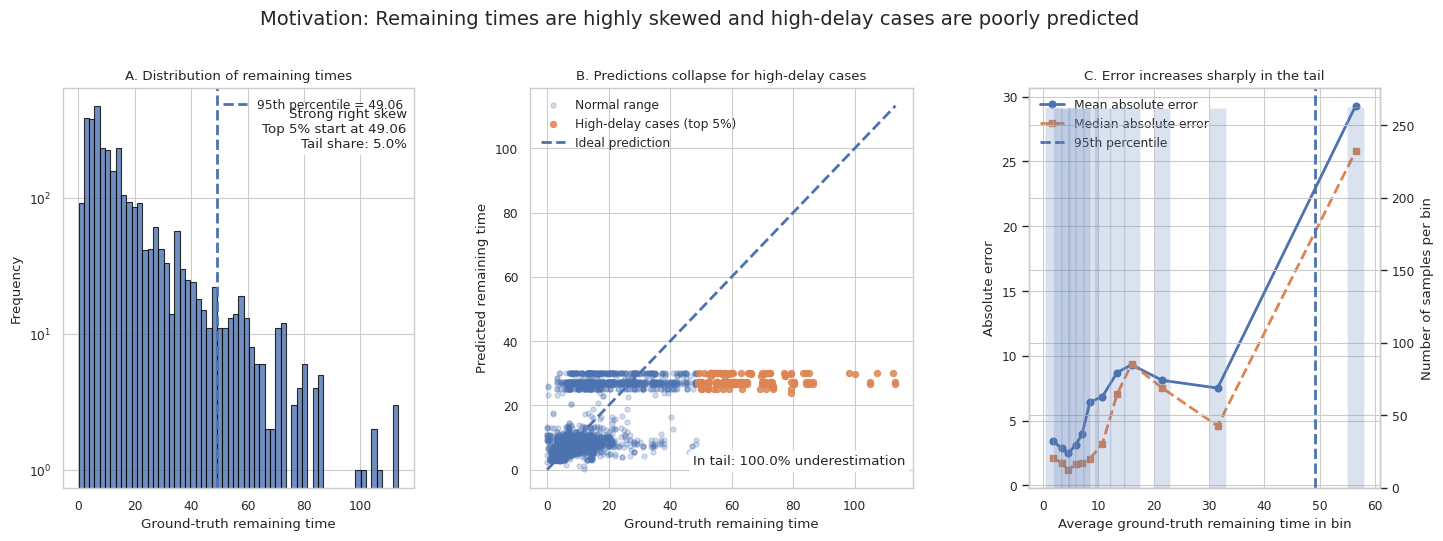

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Assumptions
# =========================
# df columns:
# ["Case_id", "Prefix_length", "GroundTruth", "Prediction", "Absolute_error"]

# Make a copy and clean
plot_df = df.copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["GroundTruth", "Prediction", "Absolute_error"]
)

# Optional: restrict to positive remaining times
plot_df = plot_df[plot_df["GroundTruth"] >= 0].copy()

# -------------------------
# Tail definition
# -------------------------
tail_quantile = 0.95
tail_threshold = plot_df["GroundTruth"].quantile(tail_quantile)
plot_df["HighDelay"] = plot_df["GroundTruth"] >= tail_threshold

# -------------------------
# Binning for error curve
# -------------------------
n_bins = 12
plot_df["GT_bin"] = pd.qcut(
    plot_df["GroundTruth"],
    q=n_bins,
    duplicates="drop"
)

bin_stats = (
    plot_df.groupby("GT_bin", observed=True)
    .agg(
        gt_mean=("GroundTruth", "mean"),
        mae_mean=("Absolute_error", "mean"),
        mae_median=("Absolute_error", "median"),
        count=("GroundTruth", "size"),
    )
    .reset_index(drop=True)
)

# -------------------------
# Figure
# -------------------------
fig = plt.figure(figsize=(17, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.2, 1.1], wspace=0.32)

# ============================================================
# Panel A: Distribution of remaining times (show skew / long tail)
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])

ax1.hist(
    plot_df["GroundTruth"],
    bins=60,
    edgecolor="black",
    alpha=0.8
)

ax1.axvline(
    tail_threshold,
    linestyle="--",
    linewidth=2,
    label=f"95th percentile = {tail_threshold:.2f}"
)

ax1.set_title("A. Distribution of remaining times")
ax1.set_xlabel("Ground-truth remaining time")
ax1.set_ylabel("Frequency")
ax1.legend(frameon=False)

# Add text box with skew story
tail_share = plot_df["HighDelay"].mean() * 100
ax1.text(
    0.98, 0.95,
    f"Strong right skew\nTop 5% start at {tail_threshold:.2f}\nTail share: {tail_share:.1f}%",
    transform=ax1.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9)
)

# Optional: log y-scale often makes the long tail more visible
ax1.set_yscale("log")

# ============================================================
# Panel B: Prediction vs ground truth (show failure on high-delay cases)
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])

# Base cloud
ax2.scatter(
    plot_df.loc[~plot_df["HighDelay"], "GroundTruth"],
    plot_df.loc[~plot_df["HighDelay"], "Prediction"],
    s=14,
    alpha=0.25,
    label="Normal range"
)

# Highlight tail cases
ax2.scatter(
    plot_df.loc[plot_df["HighDelay"], "GroundTruth"],
    plot_df.loc[plot_df["HighDelay"], "Prediction"],
    s=20,
    alpha=0.85,
    label="High-delay cases (top 5%)"
)

# Ideal diagonal
min_val = min(plot_df["GroundTruth"].min(), plot_df["Prediction"].min())
max_val = max(plot_df["GroundTruth"].max(), plot_df["Prediction"].max())
ax2.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2, label="Ideal prediction")

ax2.set_title("B. Predictions collapse for high-delay cases")
ax2.set_xlabel("Ground-truth remaining time")
ax2.set_ylabel("Predicted remaining time")
ax2.legend(frameon=False, loc="upper left")

# Zoom text
tail_df = plot_df[plot_df["HighDelay"]]
tail_underestimation = (tail_df["Prediction"] < tail_df["GroundTruth"]).mean() * 100
ax2.text(
    0.98, 0.05,
    f"In tail: {tail_underestimation:.1f}% underestimation",
    transform=ax2.transAxes,
    ha="right",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9)
)

# ============================================================
# Panel C: Error over target range (show increasing error in tail)
# ============================================================
ax3 = fig.add_subplot(gs[0, 2])

ax3.plot(
    bin_stats["gt_mean"],
    bin_stats["mae_mean"],
    marker="o",
    linewidth=2,
    label="Mean absolute error"
)

ax3.plot(
    bin_stats["gt_mean"],
    bin_stats["mae_median"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Median absolute error"
)

ax3.axvline(
    tail_threshold,
    linestyle="--",
    linewidth=2,
    label="95th percentile"
)

ax3.set_title("C. Error increases sharply in the tail")
ax3.set_xlabel("Average ground-truth remaining time in bin")
ax3.set_ylabel("Absolute error")
ax3.legend(frameon=False, loc="upper left")

# Add counts on secondary axis to show data scarcity in the tail
ax3b = ax3.twinx()
ax3b.bar(
    bin_stats["gt_mean"],
    bin_stats["count"],
    width=(bin_stats["gt_mean"].max() - bin_stats["gt_mean"].min()) / (len(bin_stats) * 1.5),
    alpha=0.2
)
ax3b.set_ylabel("Number of samples per bin")

# -------------------------
# Overall layout
# -------------------------
fig.suptitle(
    "Motivation: Remaining times are highly skewed and high-delay cases are poorly predicted",
    fontsize=14,
    y=1.03
)

plt.tight_layout()
plt.show()

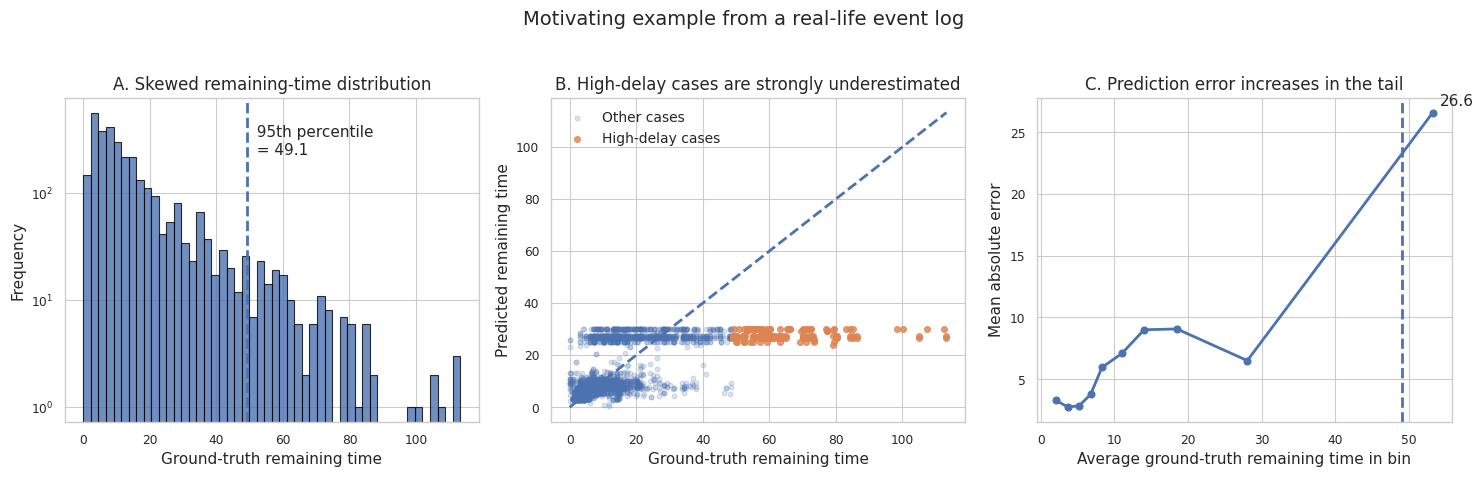

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Data prep
# --------------------------------------------------
plot_df = df.copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["GroundTruth", "Prediction", "Absolute_error"]
)
plot_df = plot_df[plot_df["GroundTruth"] >= 0].copy()

# Define high-delay cases as top 5% of remaining times
tail_q = 0.95
tail_threshold = plot_df["GroundTruth"].quantile(tail_q)
plot_df["HighDelay"] = plot_df["GroundTruth"] >= tail_threshold

# Bin ground truth for error aggregation
n_bins = 10
plot_df["GT_bin"] = pd.qcut(plot_df["GroundTruth"], q=n_bins, duplicates="drop")

bin_stats = (
    plot_df.groupby("GT_bin", observed=True)
    .agg(
        gt_mean=("GroundTruth", "mean"),
        mae_mean=("Absolute_error", "mean"),
        count=("Absolute_error", "size"),
    )
    .reset_index(drop=True)
)

# --------------------------------------------------
# Styling
# --------------------------------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
ax1, ax2, ax3 = axes

# --------------------------------------------------
# A. Distribution
# --------------------------------------------------
ax1.hist(plot_df["GroundTruth"], bins=50, edgecolor="black", alpha=0.8)
ax1.axvline(tail_threshold, linestyle="--", linewidth=2)
ax1.set_title("A. Skewed remaining-time distribution")
ax1.set_xlabel("Ground-truth remaining time")
ax1.set_ylabel("Frequency")
ax1.set_yscale("log")

# minimalist annotation
ax1.text(
    tail_threshold,
    ax1.get_ylim()[1] / 1.8,
    f"  95th percentile\n  = {tail_threshold:.1f}",
    ha="left",
    va="top"
)

# --------------------------------------------------
# B. Prediction vs truth
# --------------------------------------------------
# Plot normal cases lightly
normal = plot_df[~plot_df["HighDelay"]]
tail = plot_df[plot_df["HighDelay"]]

ax2.scatter(
    normal["GroundTruth"],
    normal["Prediction"],
    s=12,
    alpha=0.2,
    label="Other cases"
)

ax2.scatter(
    tail["GroundTruth"],
    tail["Prediction"],
    s=18,
    alpha=0.8,
    label="High-delay cases"
)

min_val = min(plot_df["GroundTruth"].min(), plot_df["Prediction"].min())
max_val = max(plot_df["GroundTruth"].max(), plot_df["Prediction"].max())
ax2.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2)

ax2.set_title("B. High-delay cases are strongly underestimated")
ax2.set_xlabel("Ground-truth remaining time")
ax2.set_ylabel("Predicted remaining time")
ax2.legend(frameon=False, loc="upper left")

# --------------------------------------------------
# C. Error by target range
# --------------------------------------------------
ax3.plot(
    bin_stats["gt_mean"],
    bin_stats["mae_mean"],
    marker="o",
    linewidth=2
)

ax3.axvline(tail_threshold, linestyle="--", linewidth=2)
ax3.set_title("C. Prediction error increases in the tail")
ax3.set_xlabel("Average ground-truth remaining time in bin")
ax3.set_ylabel("Mean absolute error")

# Optional: annotate last point only
last_x = bin_stats["gt_mean"].iloc[-1]
last_y = bin_stats["mae_mean"].iloc[-1]
ax3.annotate(
    f"{last_y:.1f}",
    xy=(last_x, last_y),
    xytext=(5, 5),
    textcoords="offset points"
)

# --------------------------------------------------
# Final layout
# --------------------------------------------------
fig.suptitle("Motivating example from a real-life event log", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

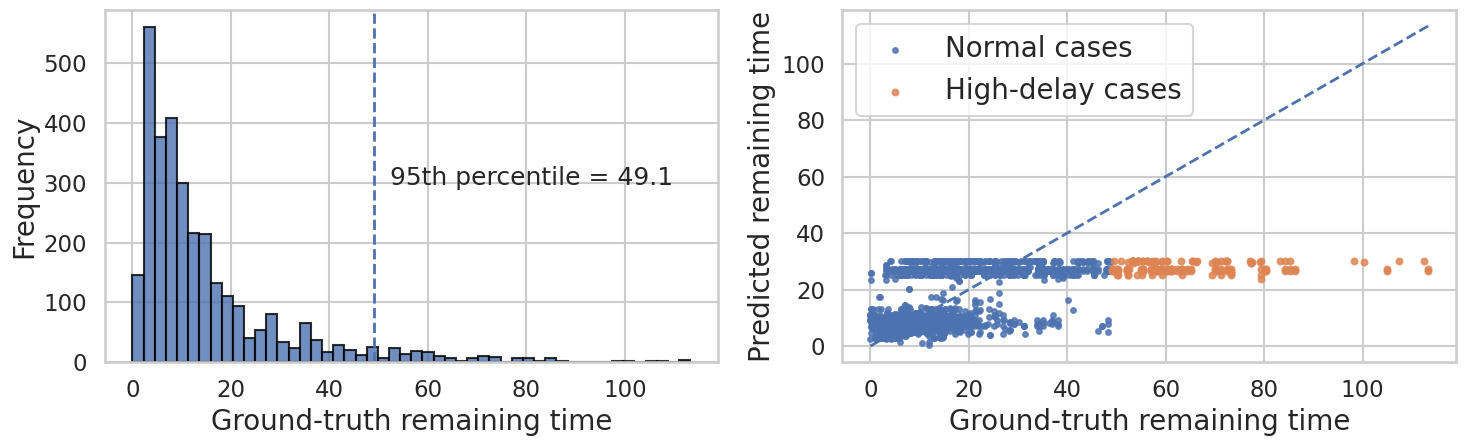

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme("talk",style="whitegrid")

# --------------------------------------------------
# Data prep
# --------------------------------------------------
plot_df = df.copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["GroundTruth", "Prediction", "Absolute_error", "Prefix_length"]
)
plot_df = plot_df[plot_df["GroundTruth"] >= 0].copy()

# Define high-delay cases as top 5% of remaining times
tail_q = 0.95
tail_threshold = plot_df["GroundTruth"].quantile(tail_q)
plot_df["DelayGroup"] = np.where(
    plot_df["GroundTruth"] >= tail_threshold,
    "High-delay cases",
    "Normal cases"
)

# --------------------------------------------------
# Aggregate error by prefix length and delay group
# --------------------------------------------------
prefix_stats = (
    plot_df.groupby(["Prefix_length", "DelayGroup"], observed=True)
    .agg(
        mae_mean=("Absolute_error", "mean"),
        mae_std=("Absolute_error", "std"),
        n=("Absolute_error", "size")
    )
    .reset_index()
)

# Standard error for optional confidence band
prefix_stats["mae_se"] = prefix_stats["mae_std"] / np.sqrt(prefix_stats["n"].clip(lower=1))

normal_stats = prefix_stats[prefix_stats["DelayGroup"] == "Normal cases"].sort_values("Prefix_length")
tail_stats = prefix_stats[prefix_stats["DelayGroup"] == "High-delay cases"].sort_values("Prefix_length")

# --------------------------------------------------
# Figure
# --------------------------------------------------
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 12,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
})

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ax1, ax2 = axes

# --------------------------------------------------
# Panel A: Distribution
# --------------------------------------------------
ax1.hist(plot_df["GroundTruth"], bins=50, edgecolor="black", alpha=0.8)
ax1.axvline(tail_threshold, linestyle="--", linewidth=2)
# ax1.set_title("A. Skewed remaining-time distribution")
ax1.set_xlabel("Ground-truth remaining time")
ax1.set_ylabel("Frequency")
# ax1.set_yscale("log")

ax1.text(
    tail_threshold,
    ax1.get_ylim()[1] / 1.8,
    f"  95th percentile = {tail_threshold:.1f}",
    ha="left",
    va="top"
)

# --------------------------------------------------
# Panel B: Prediction vs truth
# --------------------------------------------------
normal = plot_df[plot_df["DelayGroup"] == "Normal cases"]
tail = plot_df[plot_df["DelayGroup"] == "High-delay cases"]

ax2.scatter(
    normal["GroundTruth"],
    normal["Prediction"],
    s=12,
    alpha=0.8,
    label="Normal cases"
)

ax2.scatter(
    tail["GroundTruth"],
    tail["Prediction"],
    s=18,
    alpha=0.8,
    label="High-delay cases"
)

min_val = min(plot_df["GroundTruth"].min(), plot_df["Prediction"].min())
max_val = max(plot_df["GroundTruth"].max(), plot_df["Prediction"].max())
ax2.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2)

# ax2.set_title("B. High-delay cases are strongly underestimated")
ax2.set_xlabel("Ground-truth remaining time")
ax2.set_ylabel("Predicted remaining time")
ax2.legend(frameon=True, loc="upper left")

# # --------------------------------------------------
# # Panel C: Error over prefix length
# # --------------------------------------------------
# ax3.plot(
#     normal_stats["Prefix_length"],
#     normal_stats["mae_mean"],
#     marker="o",
#     linewidth=2,
#     label="Normal cases"
# )
# ax3.fill_between(
#     normal_stats["Prefix_length"],
#     normal_stats["mae_mean"] - normal_stats["mae_se"],
#     normal_stats["mae_mean"] + normal_stats["mae_se"],
#     alpha=0.2
# )

# ax3.plot(
#     tail_stats["Prefix_length"],
#     tail_stats["mae_mean"],
#     marker="o",
#     linewidth=2,
#     label="High-delay cases"
# )
# ax3.fill_between(
#     tail_stats["Prefix_length"],
#     tail_stats["mae_mean"] - tail_stats["mae_se"],
#     tail_stats["mae_mean"] + tail_stats["mae_se"],
#     alpha=0.2
# )

# ax3.set_title("C. High-delay cases remain harder across prefixes")
# ax3.set_xlabel("Prefix length")
# ax3.set_ylabel("Mean absolute error")
# ax3.legend(frameon=False, loc="upper right")

# --------------------------------------------------
# Final layout
# --------------------------------------------------
# fig.suptitle("Motivating example from a real-life event log", y=1.03, fontsize=14)
plt.tight_layout()
# save fig
fig.savefig("motivation_example.pdf", dpi=200, bbox_inches="tight")

plt.show()

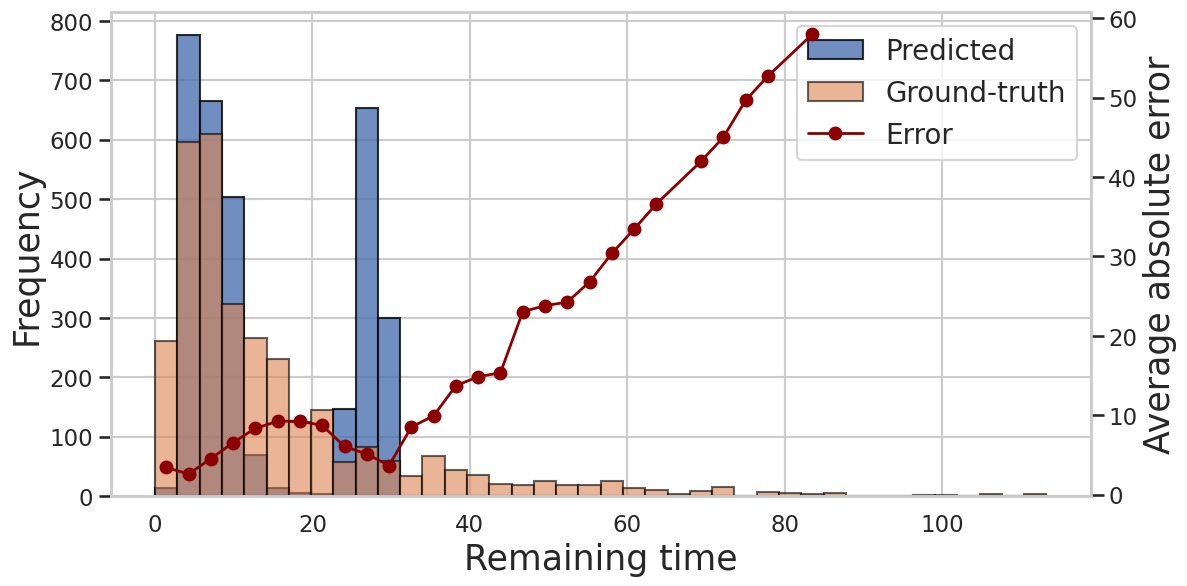

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme("talk",style="whitegrid")


# --------------------------------------------------
# Data prep
# --------------------------------------------------
plot_df = df.copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["GroundTruth", "Prediction", "Absolute_error"]
)
plot_df = plot_df[(plot_df["GroundTruth"] >= 0) & (plot_df["Prediction"] >= 0)].copy()

# --------------------------------------------------
# Common bins based on ground-truth range
# --------------------------------------------------
n_bins = 40
max_val = max(plot_df["GroundTruth"].max(), plot_df["Prediction"].max())
bins = np.linspace(0, max_val, n_bins + 1)

# Assign each sample to a ground-truth bin for error aggregation
plot_df["GT_bin"] = pd.cut(plot_df["GroundTruth"], bins=bins, include_lowest=True)

bin_stats = (
    plot_df.groupby("GT_bin", observed=True)
    .agg(
        mean_error=("Absolute_error", "mean"),
        count=("Absolute_error", "size"),
        gt_mean=("GroundTruth", "mean")
    )
    .reset_index()
)

# Use bin centers for plotting
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_stats["bin_center"] = bin_centers[:len(bin_stats)]

# Optional: only keep bins with enough samples for a stable error estimate
min_samples_per_bin = 5
bin_stats_filtered = bin_stats[bin_stats["count"] >= min_samples_per_bin].copy()

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 25,
    "legend.fontsize": 20,
})

fig, ax1 = plt.subplots(figsize=(12, 6))

# Histograms


ax1.hist(
    plot_df["Prediction"],
    bins=bins,
    alpha=0.8,
    edgecolor="black",
    label="Predicted"
)
ax1.hist(
    plot_df["GroundTruth"],
    bins=bins,
    alpha=0.6,
    edgecolor="black",
    label="Ground-truth",
)

ax1.set_xlabel("Remaining time")
ax1.set_ylabel("Frequency")
# ax1.set_yscale("log")

# Secondary axis for average error line
ax2 = ax1.twinx()
ax2.plot(
    bin_stats_filtered["bin_center"],
    bin_stats_filtered["mean_error"],
    marker="o",
    linewidth=2,
    label="Error",
    color="darkred"

)
ax2.set_ylabel("Average absolute error")
ax2.grid(False)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, frameon=True, loc="upper right")

# ax1.set_title("Distribution of ground-truth and predicted remaining times\nwith average prediction error by ground-truth bin")

plt.tight_layout()
fig.savefig("motivation_example2.pdf", dpi=200, bbox_inches="tight")
plt.show()